In [1]:
import pandas as pd

print("Working")

Working


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/train.csv")

# Show first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Number of rows and columns
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Dataset information
print("\nDataset Info:\n")
df.info()

Shape of dataset: (9800, 18)

Columns:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11

In [5]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate Rows: 0


In [7]:
# Convert date columns properly
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Check datatype
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [8]:
# Create Month and Year columns

df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Month Name'] = df['Order Date'].dt.month_name()

# Show first rows
df[['Order Date', 'Month', 'Year', 'Month Name']].head()

,Order Date,Month,Year,Month Name
0,2017-11-08,11,2017,November
1,2017-11-08,11,2017,November
2,2017-06-12,6,2017,June
3,2016-10-11,10,2016,October
4,2016-10-11,10,2016,October


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Monthly sales analysis

monthly_sales = df.groupby('Month Name')['Sales'].sum()

print(monthly_sales)

Month Name
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


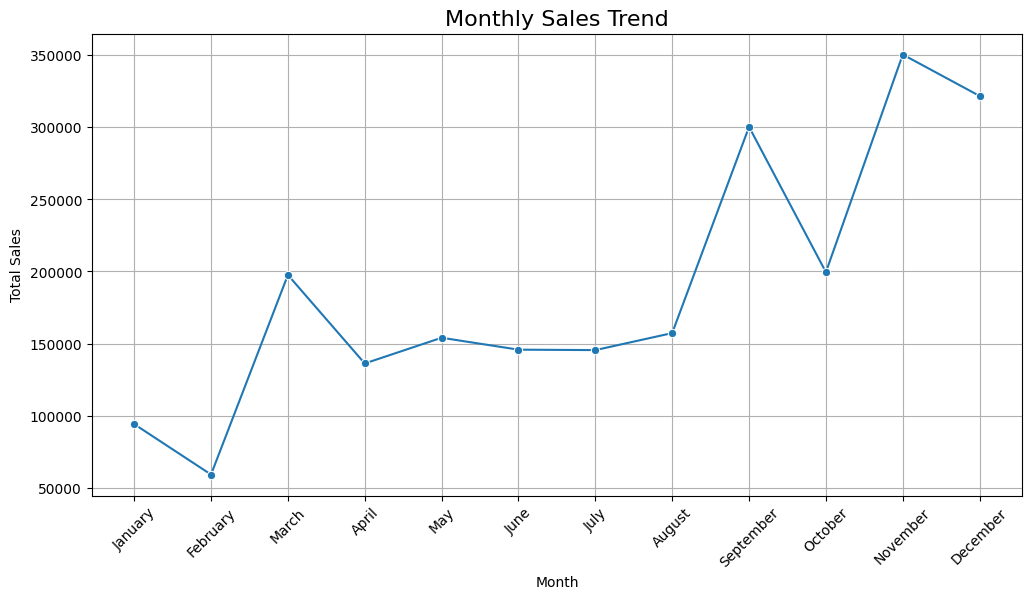

In [11]:
# Correct month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Group sales by month
monthly_sales = df.groupby('Month Name')['Sales'].sum()

# Reorder months
monthly_sales = monthly_sales.reindex(month_order)

# Chart size
plt.figure(figsize=(12,6))

# Create line plot
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o'
)

# Titles and labels
plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")

# Rotate month names
plt.xticks(rotation=45)

# Grid
plt.grid(True)

# Show chart
plt.show()

In [12]:
# Category-wise sales

category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


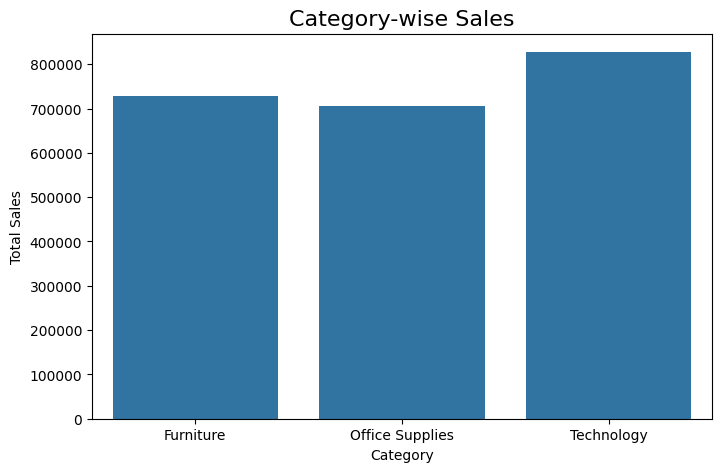

In [13]:
# Chart size
plt.figure(figsize=(8,5))

# Bar chart
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

# Title and labels
plt.title("Category-wise Sales", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Show chart
plt.show()

In [14]:
# Region-wise sales

region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


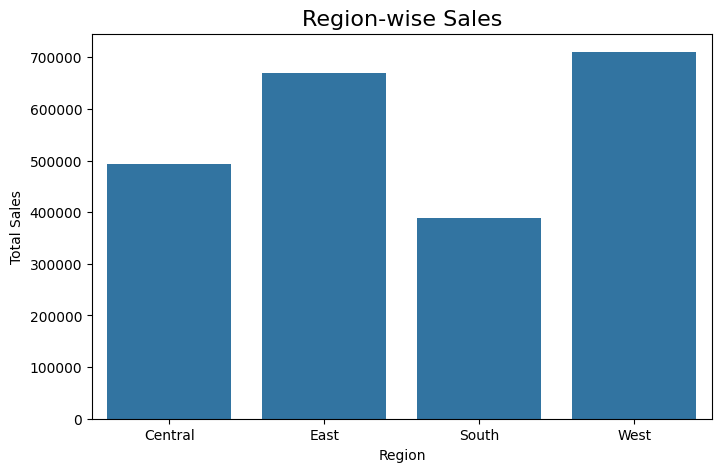

In [15]:
# Chart size
plt.figure(figsize=(8,5))

# Bar chart
sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

# Titles and labels
plt.title("Region-wise Sales", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Total Sales")

# Show chart
plt.show()

In [16]:
# Top 10 products by sales

top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


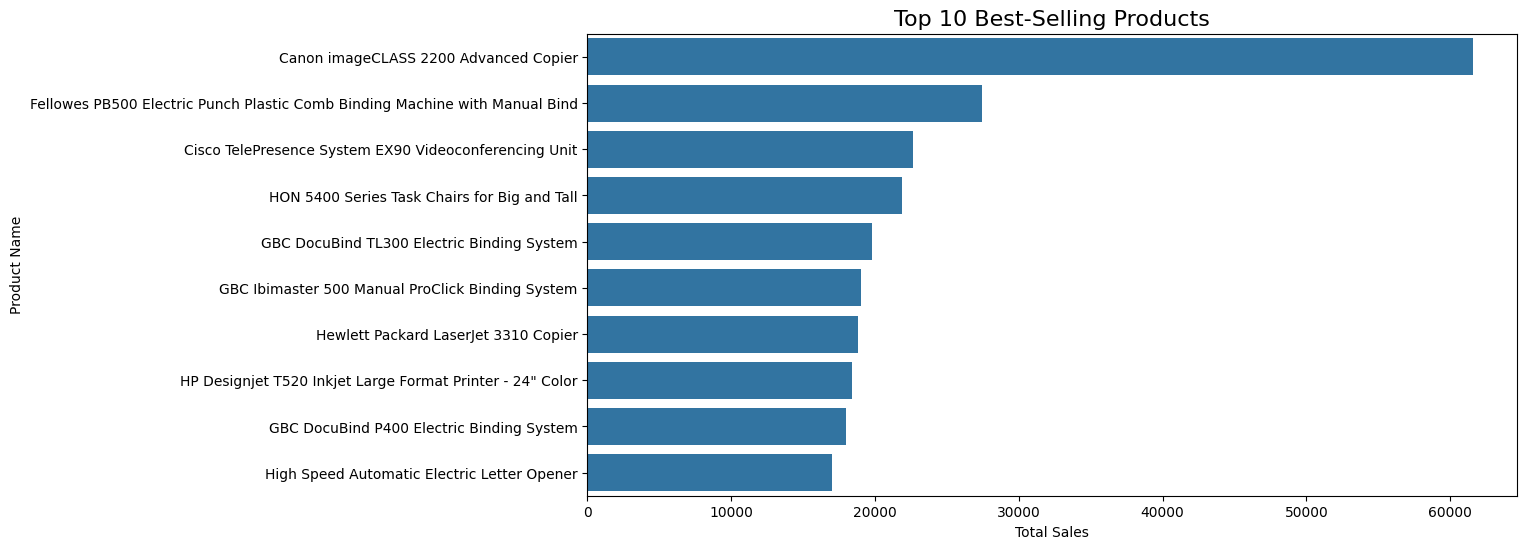

In [17]:
# Chart size
plt.figure(figsize=(12,6))

# Horizontal bar chart
sns.barplot(
    x=top_products.values,
    y=top_products.index
)

# Titles and labels
plt.title("Top 10 Best-Selling Products", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

# Show chart
plt.show()

In [18]:
# Sales by customer segment

segment_sales = df.groupby('Segment')['Sales'].sum()

print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


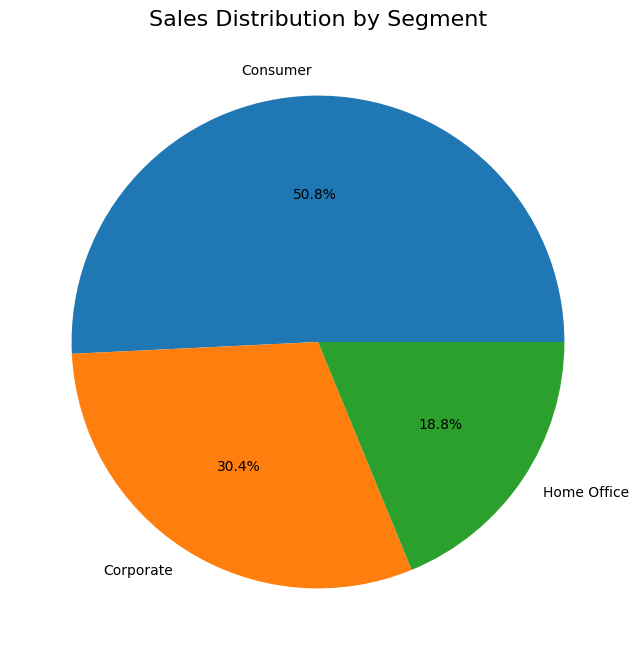

In [19]:
# Chart size
plt.figure(figsize=(8,8))

# Pie chart
plt.pie(
    segment_sales.values,
    labels=segment_sales.index,
    autopct='%1.1f%%'
)

# Title
plt.title("Sales Distribution by Segment", fontsize=16)

# Show chart
plt.show()

In [20]:
# KPI Metrics

total_sales = df['Sales'].sum()

total_orders = df['Order ID'].nunique()

total_customers = df['Customer ID'].nunique()

total_categories = df['Category'].nunique()

print("===== KPI SUMMARY =====")

print(f"Total Sales: ${total_sales:,.2f}")

print(f"Total Orders: {total_orders}")

print(f"Total Customers: {total_customers}")

print(f"Total Categories: {total_categories}")

===== KPI SUMMARY =====
Total Sales: $2,261,536.78
Total Orders: 4922
Total Customers: 793
Total Categories: 3


In [21]:
# Professional chart styling

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

plt.rcParams['font.size'] = 12

In [22]:
plt.show()

In [23]:
plt.savefig("images/chart_name.png")


<Figure size 1000x600 with 0 Axes>

In [24]:
plt.savefig("images/monthly_sales_trend.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

# Business Insights

- Technology category generated the highest sales revenue.
- West region achieved the strongest overall sales performance.
- Consumer segment contributed the highest percentage of total sales.
- Sales peaked during November and December, indicating strong seasonal demand.
- Several products significantly outperformed others in total revenue generation.

# Conclusion

This analysis explored superstore sales data to identify key business trends and performance indicators.

Major findings include:
- Technology products generated the highest sales revenue.
- The West region performed better compared to other regions.
- Consumer customers contributed the largest share of sales.
- Sales increased significantly during the end-of-year months.

The dashboard and visualizations provide valuable business insights that can help improve decision-making, marketing strategies, and sales planning.